# Norm-Exp-Two-Sided: исправленный экспериментальный ноутбук

Этот ноутбук — исправленная и более воспроизводимая версия экспериментов для курсовой работы про проекторно-нормированные ранго-сохраняющие методы.

Главные исправления относительно предыдущей версии:

1. **Factor-GD и ScaledGD исправлены на одновременное обновление факторов**: оба градиента считаются в точке \((U_k,V_k)\), а не последовательно через уже обновлённый \(U\).
2. **Loss-метрики согласованы с моделью данных**: train/validation/test считаются по шумным наблюдениям \(Y=M_\star+\xi\), а full relative error и hidden clean loss — по чистой матрице \(M_\star\).
3. **Grid для старого Exp-Two-Sided расширен** до больших шагов, чтобы лучший шаг не оказывался искусственно на правой границе сетки.
4. **Tangent-Match-Exp вынесен как optional extra**, чтобы не засорять основные таблицы, если он не описан в тексте курсовой.
5. **Rank mismatch дополнен oracle best-rank-r ошибкой** для самой истинной матрицы, чтобы корректно объяснять случаи, когда \(r<r_\star\) даёт меньшую ошибку.
6. **Runtime сделан повторяемым**: несколько повторов, mean/std и time per iteration.
7. **Все ключевые графики сохраняются в `figures/`**, а таблицы — в `results/`, чтобы их можно было вставить в LaTeX.

Рекомендуемый режим:

- `DEFAULT_MODE = 'fast'` — проверка, что всё запускается;
- `DEFAULT_MODE = 'balanced'` — адекватные результаты для курсовой;
- `DEFAULT_MODE = 'thorough'` — более тяжёлый прогон перед финальной сдачей.


## 0. Imports and global settings


In [1]:
import os
import time
import math
import warnings
from dataclasses import dataclass
from pathlib import Path
from typing import Dict, Any, Optional, List, Tuple, Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.linalg import svd, expm
from IPython.display import display

warnings.filterwarnings('ignore')
np.set_printoptions(precision=4, suppress=True)

# Быстрый режим нужен для проверки корректности ноутбука.
# Для финальных таблиц курсовой лучше использовать 'balanced' или 'thorough'.
DEFAULT_MODE = 'thorough'  # 'fast', 'balanced', or 'thorough'

ROOT = Path('.')
FIG_DIR = ROOT / 'figures'
RES_DIR = ROOT / 'results'
FIG_DIR.mkdir(exist_ok=True)
RES_DIR.mkdir(exist_ok=True)

SAVE_FIGURES = True
SAVE_TABLES = True

SEED_GLOBAL = 0
RNG_GLOBAL = np.random.default_rng(SEED_GLOBAL)

print(f'DEFAULT_MODE = {DEFAULT_MODE}')
print(f'Figures will be saved to: {FIG_DIR.resolve()}')
print(f'Results will be saved to: {RES_DIR.resolve()}')


DEFAULT_MODE = thorough
Figures will be saved to: /content/figures
Results will be saved to: /content/results


## 1. Вспомогательная линейная алгебра

Нам нужны усечённое SVD, проекция \(\mathcal P_r\), псевдообратная ранга \(r\), касательная проекция и спектральные метрики.


In [2]:
def thin_svd(A: np.ndarray, r: Optional[int] = None):
    """Compute thin SVD. If r is given, return only first r components."""
    U, s, Vt = svd(A, full_matrices=False, check_finite=False)
    if r is not None:
        rr = min(r, len(s))
        U = U[:, :rr]
        s = s[:rr]
        Vt = Vt[:rr, :]
    return U, s, Vt


def best_rank_r(A: np.ndarray, r: int) -> np.ndarray:
    """Best rank-r approximation in Frobenius norm via truncated SVD."""
    U, s, Vt = thin_svd(A, r)
    return (U * s) @ Vt


def svt(A: np.ndarray, tau: float) -> np.ndarray:
    """Singular value thresholding: S_tau(A)."""
    U, s, Vt = thin_svd(A)
    s2 = np.maximum(s - tau, 0.0)
    keep = s2 > 0
    if not np.any(keep):
        return np.zeros_like(A)
    return (U[:, keep] * s2[keep]) @ Vt[keep, :]


def pinv_rank(A: np.ndarray, r: int, eps: float = 1e-12) -> np.ndarray:
    """
    Rank-r pseudoinverse based on truncated SVD.

    A = U S V^T, A^+ = V S^{-1} U^T.
    Small singular values are floored for numerical stability.
    """
    U, s, Vt = thin_svd(A, r)
    if len(s) == 0:
        return np.zeros((A.shape[1], A.shape[0]))
    floor = eps * max(1.0, float(s[0]))
    inv_s = 1.0 / np.maximum(s, floor)
    return Vt.T @ (inv_s[:, None] * U.T)


def projectors_from_A(A: np.ndarray, r: int):
    """Return U, s, Vt, P_U, P_V for rank-r approximation of A."""
    U, s, Vt = thin_svd(A, r)
    V = Vt.T
    P_U = U @ U.T
    P_V = V @ V.T
    return U, s, Vt, P_U, P_V


def normalized_direction(G: np.ndarray, A: np.ndarray, r: int) -> np.ndarray:
    """
    D(A)=G V V^T + U U^T G, implemented without forming full projectors.
    """
    U, s, Vt = thin_svd(A, r)
    V = Vt.T
    return (G @ V) @ V.T + U @ (U.T @ G)


def tangent_projection(G: np.ndarray, A: np.ndarray, r: int) -> np.ndarray:
    """
    Projection of G onto the tangent space of the fixed-rank manifold at A.

    If A = U S V^T, then
        P_T(G) = P_U G + G P_V - P_U G P_V.
    Implemented without explicitly forming P_U and P_V.
    """
    U, s, Vt = thin_svd(A, r)
    V = Vt.T
    PU_G = U @ (U.T @ G)
    G_PV = (G @ V) @ V.T
    PU_G_PV = U @ (U.T @ G @ V) @ V.T
    return PU_G + G_PV - PU_G_PV


def numerical_rank(A: np.ndarray, tol: float = 1e-8) -> int:
    s = svd(A, compute_uv=False, check_finite=False)
    if len(s) == 0:
        return 0
    return int(np.sum(s > tol * max(A.shape) * max(float(s[0]), 1.0)))


def spectral_metrics(A: np.ndarray, r: int) -> Dict[str, float]:
    s = svd(A, compute_uv=False, check_finite=False)
    out = {
        'rank_num': numerical_rank(A),
        'sigma_1': float(s[0]) if len(s) else 0.0,
        'sigma_r': float(s[r-1]) if len(s) >= r else 0.0,
        'cond_r': np.nan,
    }
    if len(s) >= r and s[r-1] > 0:
        out['cond_r'] = float(s[0] / s[r-1])
    return out


def rel_error(A: np.ndarray, B: np.ndarray) -> float:
    return float(np.linalg.norm(A - B, 'fro') / max(np.linalg.norm(B, 'fro'), 1e-15))


def best_rank_errors(M: np.ndarray, ranks: Iterable[int]) -> pd.DataFrame:
    rows = []
    for r in ranks:
        rr = min(int(r), min(M.shape))
        Mr = best_rank_r(M, rr)
        rows.append({'fit_rank': int(r), 'oracle_best_rank_rel_error': rel_error(Mr, M)})
    return pd.DataFrame(rows)


## 2. Генерация данных для matrix completion

Синтетическая модель:

\[
Y_{ij}=M_{\star,ij}+\xi_{ij}, \qquad (i,j)\in\Omega.
\]

Обучение, validation и test loss считаются по шумным наблюдениям \(Y\), потому что именно они доступны алгоритму. Для синтетической диагностики дополнительно считаем:

\[
\frac{\|A-M_\star\|_F}{\|M_\star\|_F}
\]

и hidden clean loss на ненаблюдавшихся элементах относительно чистой матрицы \(M_\star\).


In [3]:
def random_orthonormal(n: int, r: int, rng: np.random.Generator) -> np.ndarray:
    Q, _ = np.linalg.qr(rng.standard_normal((n, r)))
    return Q[:, :r]


def make_low_rank_matrix(
    m: int,
    n: int,
    r: int,
    cond: float = 10.0,
    rng: Optional[np.random.Generator] = None,
    spectrum: str = 'log',
    normalize: bool = True,
) -> np.ndarray:
    """Generate an m x n rank-r matrix with controlled condition number."""
    rng = np.random.default_rng() if rng is None else rng
    U = random_orthonormal(m, r, rng)
    V = random_orthonormal(n, r, rng)

    if r == 1:
        s = np.array([1.0])
    elif spectrum == 'log':
        s = np.geomspace(1.0, 1.0 / cond, r)
    elif spectrum == 'linear':
        s = np.linspace(1.0, 1.0 / cond, r)
    else:
        raise ValueError("spectrum must be 'log' or 'linear'")

    M = (U * s) @ V.T
    if normalize:
        M = M / max(np.linalg.norm(M, 'fro'), 1e-15)
    return M


def split_observed_mask(
    m: int,
    n: int,
    obs_prob: float,
    rng: np.random.Generator,
    train_frac: float = 0.70,
    val_frac: float = 0.15,
    test_frac: float = 0.15,
):
    """Create train/val/test masks from observed entries."""
    assert abs(train_frac + val_frac + test_frac - 1.0) < 1e-12
    observed = rng.random((m, n)) < obs_prob
    idx = np.argwhere(observed)
    rng.shuffle(idx)

    N = len(idx)
    n_train = int(train_frac * N)
    n_val = int(val_frac * N)

    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train+n_val]
    test_idx = idx[n_train+n_val:]

    train_mask = np.zeros((m, n), dtype=bool)
    val_mask = np.zeros((m, n), dtype=bool)
    test_mask = np.zeros((m, n), dtype=bool)

    if len(train_idx):
        train_mask[train_idx[:, 0], train_idx[:, 1]] = True
    if len(val_idx):
        val_mask[val_idx[:, 0], val_idx[:, 1]] = True
    if len(test_idx):
        test_mask[test_idx[:, 0], test_idx[:, 1]] = True

    return train_mask, val_mask, test_mask


@dataclass
class MatrixCompletionProblem:
    M_star: np.ndarray
    train_mask: np.ndarray
    val_mask: np.ndarray
    test_mask: np.ndarray
    noise_std: float = 0.0
    seed: int = 0

    def __post_init__(self):
        rng = np.random.default_rng(self.seed + 12345)
        noise = self.noise_std * rng.standard_normal(self.M_star.shape)
        self.M_obs = self.M_star + noise
        self.m, self.n = self.M_star.shape

    def _masked_mse_obs(self, A: np.ndarray, mask: np.ndarray) -> float:
        """MSE against noisy observed matrix Y. Used for train/val/test."""
        count = int(mask.sum())
        if count == 0:
            return np.nan
        R = (A - self.M_obs)[mask]
        return float(0.5 * np.mean(R ** 2))

    def _masked_mse_clean(self, A: np.ndarray, mask: np.ndarray) -> float:
        """MSE against clean M_star. Used only for synthetic diagnostics."""
        count = int(mask.sum())
        if count == 0:
            return np.nan
        R = (A - self.M_star)[mask]
        return float(0.5 * np.mean(R ** 2))

    def loss(self, A: np.ndarray) -> float:
        return self._masked_mse_obs(A, self.train_mask)

    def val_loss(self, A: np.ndarray) -> float:
        return self._masked_mse_obs(A, self.val_mask)

    def test_loss(self, A: np.ndarray) -> float:
        return self._masked_mse_obs(A, self.test_mask)

    def full_rel_error(self, A: np.ndarray) -> float:
        return rel_error(A, self.M_star)

    def hidden_clean_loss(self, A: np.ndarray) -> float:
        hidden = ~(self.train_mask | self.val_mask | self.test_mask)
        return self._masked_mse_clean(A, hidden)

    def train_clean_loss(self, A: np.ndarray) -> float:
        return self._masked_mse_clean(A, self.train_mask)

    def grad(self, A: np.ndarray) -> np.ndarray:
        """Gradient of train observed loss with respect to noisy observations Y."""
        count = max(int(self.train_mask.sum()), 1)
        G = np.zeros_like(A)
        G[self.train_mask] = (A - self.M_obs)[self.train_mask] / count
        return G


def spectral_initialization_mc(problem: MatrixCompletionProblem, r: int) -> np.ndarray:
    """
    Spectral initialization from train observations.

    Missing entries are filled with zero, and observed entries are scaled by
    the train observation probability.
    """
    Y = np.zeros_like(problem.M_star)
    Y[problem.train_mask] = problem.M_obs[problem.train_mask]
    p_train = max(problem.train_mask.mean(), 1e-12)
    return best_rank_r(Y / p_train, r)


def make_matrix_completion_instance(
    m: int = 50,
    n: int = 45,
    true_rank: int = 4,
    fit_rank: Optional[int] = None,
    cond: float = 50.0,
    obs_prob: float = 0.30,
    noise_std: float = 1e-3,
    seed: int = 0,
):
    rng = np.random.default_rng(seed)
    M_star = make_low_rank_matrix(m, n, true_rank, cond=cond, rng=rng)
    train_mask, val_mask, test_mask = split_observed_mask(m, n, obs_prob, rng)
    problem = MatrixCompletionProblem(M_star, train_mask, val_mask, test_mask,
                                      noise_std=noise_std, seed=seed)
    r = true_rank if fit_rank is None else fit_rank
    A0 = spectral_initialization_mc(problem, r)
    return problem, A0, r, M_star


## 3. Методы оптимизации

Важное исправление: Factor-GD и ScaledGD ниже используют **одновременное** обновление \(U,V\). То есть сначала сохраняются \(U_k,V_k\), затем оба новых фактора считаются из одной и той же точки.


In [4]:
def log_metrics(problem, A, r, method_name, iteration, start_time):
    row = {
        'method': method_name,
        'iter': int(iteration),
        'train_loss': problem.loss(A),
        'val_loss': problem.val_loss(A),
        'test_loss': problem.test_loss(A),
        'hidden_clean_loss': problem.hidden_clean_loss(A),
        'train_clean_loss': problem.train_clean_loss(A),
        'full_rel_error': problem.full_rel_error(A),
        'time': time.perf_counter() - start_time,
    }
    row.update(spectral_metrics(A, r))
    return row


def run_matrix_method(problem, A0, r, n_iter, eval_every, step_fn, method_name, **params):
    A = np.array(A0, copy=True)
    rows = []
    start = time.perf_counter()
    rows.append(log_metrics(problem, A, r, method_name, 0, start))

    for k in range(1, n_iter + 1):
        A = step_fn(problem, A, r, **params)
        if not np.all(np.isfinite(A)):
            raise FloatingPointError(f'{method_name} produced non-finite values at iter={k}')
        if k % eval_every == 0 or k == n_iter:
            rows.append(log_metrics(problem, A, r, method_name, k, start))

    return pd.DataFrame(rows), A


# ---------- direct matrix methods ----------

def step_svp(problem, A, r, eta):
    G = problem.grad(A)
    return best_rank_r(A - eta * G, r)


def step_riemannian_gd(problem, A, r, eta):
    G = problem.grad(A)
    TG = tangent_projection(G, A, r)
    return best_rank_r(A - eta * TG, r)


def step_nuclear_prox(problem, A, r, eta, lamb):
    # This method does not preserve fixed rank; it is reported separately.
    G = problem.grad(A)
    return svt(A - eta * G, eta * lamb)


def step_exp_one_sided(problem, A, r, eta):
    G = problem.grad(A)
    return expm(-eta * (G @ A.T)) @ A


def step_exp_two_sided(problem, A, r, eta):
    G = problem.grad(A)
    return expm(-eta * (G @ A.T)) @ A @ expm(-eta * (A.T @ G))


def step_norm_exp_two_sided(problem, A, r, eta, pinv_eps=1e-12):
    G = problem.grad(A)
    Ap = pinv_rank(A, r, eps=pinv_eps)
    return expm(-eta * (G @ Ap)) @ A @ expm(-eta * (Ap @ G))


def step_euler_norm_two_sided(problem, A, r, eta, project_rank=True, pinv_eps=1e-12):
    """First-order ablation of Norm-Exp-Two-Sided."""
    G = problem.grad(A)
    D = normalized_direction(G, A, r)
    A_new = A - eta * D
    if project_rank:
        A_new = best_rank_r(A_new, r)
    return A_new


def step_tangent_match_exp(problem, A, r, eta, pinv_eps=1e-12):
    """
    Optional diagnostic exponential step whose first-order term matches Riemannian-GD.
    Use it only if it is described in the text; otherwise exclude from main tables.
    """
    G = problem.grad(A)
    xi = -tangent_projection(G, A, r)
    Ap = pinv_rank(A, r, eps=pinv_eps)
    P_U = A @ Ap
    P_V = Ap @ A
    X = (np.eye(A.shape[0]) - 0.5 * P_U) @ xi @ Ap
    Y = Ap @ xi @ (np.eye(A.shape[1]) - 0.5 * P_V)
    return expm(eta * X) @ A @ expm(eta * Y)


def run_svp(problem, A0, r, n_iter=500, eval_every=10, method_name='SVP', eta=1.0, **kw):
    return run_matrix_method(problem, A0, r, n_iter, eval_every, step_svp, method_name, eta=eta)


def run_riemannian_gd(problem, A0, r, n_iter=500, eval_every=10, method_name='Riemannian-GD', eta=1.0, **kw):
    return run_matrix_method(problem, A0, r, n_iter, eval_every, step_riemannian_gd, method_name, eta=eta)


def run_nuclear_prox(problem, A0, r, n_iter=500, eval_every=10, method_name='Nuclear-Prox', eta=1.0, lamb=1e-3, **kw):
    return run_matrix_method(problem, A0, r, n_iter, eval_every, step_nuclear_prox, method_name, eta=eta, lamb=lamb)


def run_exp_one_sided(problem, A0, r, n_iter=500, eval_every=10, method_name='Exp-One-Sided', eta=1.0, **kw):
    return run_matrix_method(problem, A0, r, n_iter, eval_every, step_exp_one_sided, method_name, eta=eta)


def run_exp_two_sided(problem, A0, r, n_iter=500, eval_every=10, method_name='Exp-Two-Sided', eta=1.0, **kw):
    return run_matrix_method(problem, A0, r, n_iter, eval_every, step_exp_two_sided, method_name, eta=eta)


def run_norm_exp_two_sided(problem, A0, r, n_iter=500, eval_every=10, method_name='Norm-Exp-Two-Sided', eta=1.0, pinv_eps=1e-12, **kw):
    return run_matrix_method(problem, A0, r, n_iter, eval_every, step_norm_exp_two_sided, method_name, eta=eta, pinv_eps=pinv_eps)


def run_euler_norm_two_sided(problem, A0, r, n_iter=500, eval_every=10, method_name='Euler-Norm-Two-Sided', eta=1.0, project_rank=True, pinv_eps=1e-12, **kw):
    return run_matrix_method(problem, A0, r, n_iter, eval_every, step_euler_norm_two_sided, method_name, eta=eta, project_rank=project_rank, pinv_eps=pinv_eps)


def run_tangent_match_exp(problem, A0, r, n_iter=500, eval_every=10, method_name='Tangent-Match-Exp', eta=1.0, **kw):
    return run_matrix_method(problem, A0, r, n_iter, eval_every, step_tangent_match_exp, method_name, eta=eta)


# ---------- factorized methods ----------

def init_factors_from_A(A0: np.ndarray, r: int):
    U, s, Vt = thin_svd(A0, r)
    sqrt_s = np.sqrt(np.maximum(s, 0.0))
    return U * sqrt_s, Vt.T * sqrt_s


def run_factor_gd(problem, A0, r, n_iter=500, eval_every=10,
                  method_name='Factor-GD', eta=1e-2, max_factor_norm=1e12, **kw):
    U, V = init_factors_from_A(A0, r)
    rows = []
    start = time.perf_counter()
    rows.append(log_metrics(problem, U @ V.T, r, method_name, 0, start))

    for k in range(1, n_iter + 1):
        A = U @ V.T
        G = problem.grad(A)

        # Correct simultaneous update: both gradients are evaluated at (U_k, V_k).
        U_old = U.copy()
        V_old = V.copy()
        U = U_old - eta * (G @ V_old)
        V = V_old - eta * (G.T @ U_old)

        if (not np.all(np.isfinite(U)) or not np.all(np.isfinite(V)) or
            np.linalg.norm(U, 'fro') > max_factor_norm or np.linalg.norm(V, 'fro') > max_factor_norm):
            raise FloatingPointError(f'{method_name} produced unstable factors at iter={k}')
        if k % eval_every == 0 or k == n_iter:
            rows.append(log_metrics(problem, U @ V.T, r, method_name, k, start))

    return pd.DataFrame(rows), U @ V.T


def run_scaled_gd(problem, A0, r, n_iter=500, eval_every=10,
                  method_name='ScaledGD', eta=1e-1, damping=1e-6,
                  max_factor_norm=1e12, **kw):
    U, V = init_factors_from_A(A0, r)
    rows = []
    start = time.perf_counter()
    rows.append(log_metrics(problem, U @ V.T, r, method_name, 0, start))

    for k in range(1, n_iter + 1):
        A = U @ V.T
        G = problem.grad(A)

        # Correct simultaneous ScaledGD update.
        # We use solve(X, B.T).T instead of explicit inverse for better numerical stability:
        #   (G V)(V^T V + eps I)^{-1}
        # = solve(V^T V + eps I, (G V)^T)^T.
        U_old = U.copy()
        V_old = V.copy()

        VtV = V_old.T @ V_old + damping * np.eye(r)
        UtU = U_old.T @ U_old + damping * np.eye(r)

        U_step = np.linalg.solve(VtV, (G @ V_old).T).T
        V_step = np.linalg.solve(UtU, (G.T @ U_old).T).T

        U = U_old - eta * U_step
        V = V_old - eta * V_step

        if (not np.all(np.isfinite(U)) or not np.all(np.isfinite(V)) or
            np.linalg.norm(U, 'fro') > max_factor_norm or np.linalg.norm(V, 'fro') > max_factor_norm):
            raise FloatingPointError(f'{method_name} produced unstable factors at iter={k}')
        if k % eval_every == 0 or k == n_iter:
            rows.append(log_metrics(problem, U @ V.T, r, method_name, k, start))

    return pd.DataFrame(rows), U @ V.T


## 4. Подбор learning rate

Шаги подбираются по validation loss. Старый Exp-Two-Sided получил расширенную сетку до больших значений, потому что в предыдущей версии лучший шаг часто оказывался на правой границе.


In [5]:
RUNNERS = {
    'SVP': run_svp,
    'Factor-GD': run_factor_gd,
    'ScaledGD': run_scaled_gd,
    'Riemannian-GD': run_riemannian_gd,
    'Nuclear-Prox': run_nuclear_prox,
    'Exp-One-Sided': run_exp_one_sided,
    'Exp-Two-Sided': run_exp_two_sided,
    'Norm-Exp-Two-Sided': run_norm_exp_two_sided,
    'Euler-Norm-Two-Sided': run_euler_norm_two_sided,
    'Tangent-Match-Exp': run_tangent_match_exp,
}


def log_grid(a: float, b: float, num: int) -> np.ndarray:
    return np.logspace(np.log10(a), np.log10(b), num)


def _cfg(runner, grid):
    return {'runner': runner, 'grid': grid}


def matrix_completion_configs(mode: str = 'fast', include_exp_old=True, include_extra=False, include_nuclear=False):
    """
    Hyperparameter grids for matrix completion.

    include_extra=False by default because Tangent-Match-Exp should not appear in main
    tables unless it is explicitly described in the written text.
    include_nuclear=False by default because Nuclear-Prox does not preserve fixed rank.
    """
    if mode == 'fast':
        n = 9
        n_nuc_eta = 5
        n_nuc_lam = 4
    elif mode == 'balanced':
        n = 15
        n_nuc_eta = 7
        n_nuc_lam = 6
    elif mode == 'thorough':
        n = 25
        n_nuc_eta = 11
        n_nuc_lam = 9
    else:
        raise ValueError("mode must be 'fast', 'balanced', or 'thorough'")

    configs = {
        'SVP': _cfg(run_svp, [{'eta': float(e)} for e in log_grid(1e-1, 1e4, n)]),
        'Factor-GD': _cfg(run_factor_gd, [{'eta': float(e)} for e in log_grid(1e-3, 1e3, n)]),
        'ScaledGD': _cfg(run_scaled_gd, [{'eta': float(e), 'damping': 1e-6} for e in log_grid(1e-3, 1e2, n)]),
        'Riemannian-GD': _cfg(run_riemannian_gd, [{'eta': float(e)} for e in log_grid(1e-1, 1e4, n)]),
        'Norm-Exp-Two-Sided': _cfg(run_norm_exp_two_sided, [{'eta': float(e), 'pinv_eps': 1e-12} for e in log_grid(1e-4, 1e4, n)]),
        'Euler-Norm-Two-Sided': _cfg(run_euler_norm_two_sided, [{'eta': float(e), 'project_rank': True, 'pinv_eps': 1e-12} for e in log_grid(1e-2, 1e4, n)]),
    }

    if include_exp_old:
        configs['Exp-One-Sided'] = _cfg(run_exp_one_sided, [{'eta': float(e)} for e in log_grid(1e-5, 1e3, n)])
        # Expanded upper bound: old version ended at 1e2, often on the boundary.
        configs['Exp-Two-Sided'] = _cfg(run_exp_two_sided, [{'eta': float(e)} for e in log_grid(1e-6, 1e4, n)])

    if include_nuclear:
        configs['Nuclear-Prox'] = _cfg(run_nuclear_prox, [
            {'eta': float(e), 'lamb': float(l)}
            for e in log_grid(1e-1, 1e4, n_nuc_eta)
            for l in log_grid(1e-8, 1e-1, n_nuc_lam)
        ])

    if include_extra:
        configs['Tangent-Match-Exp'] = _cfg(run_tangent_match_exp, [{'eta': float(e)} for e in log_grid(1e-2, 1e4, n)])

    return configs


def is_boundary_choice(params: Dict[str, Any], grid: List[Dict[str, Any]], key='eta') -> bool:
    if params is None or key not in params:
        return False
    values = sorted({float(g[key]) for g in grid if key in g})
    if not values:
        return False
    x = float(params[key])
    return np.isclose(x, values[0]) or np.isclose(x, values[-1])


def evaluate_grid(problem, A0, r, method_name, cfg, tune_iter=200, eval_every=None, score_key='val_loss'):
    if eval_every is None:
        eval_every = tune_iter
    runner = cfg['runner']
    best_score = np.inf
    best_params = None
    trials = []

    for params in cfg['grid']:
        trial = {'method': method_name, **params}
        try:
            hist, _ = runner(problem, A0, r=r, n_iter=tune_iter, eval_every=eval_every,
                             method_name=method_name, **params)
            score = float(hist[score_key].iloc[-1]) if score_key in hist.columns else float(hist['val_loss'].iloc[-1])
            stable = np.isfinite(score) and np.all(np.isfinite(hist.select_dtypes(include=[np.number]).values))
            trial.update({'score': score, 'stable': stable})
            if stable and score < best_score:
                best_score = score
                best_params = dict(params)
        except Exception as exc:
            trial.update({'score': np.inf, 'stable': False, 'error': repr(exc)})
        trials.append(trial)

    trials_df = pd.DataFrame(trials)
    boundary = is_boundary_choice(best_params, cfg['grid'], key='eta')
    return best_params, best_score, trials_df, boundary


def _params_key(params: Dict[str, Any]) -> tuple:
    """Hashable representation of a parameter dictionary."""
    return tuple(sorted(params.items()))


def tune_and_run(problem, A0, r, configs, tune_iter=200, n_iter=1000, eval_every=20,
                 score_key='val_loss', verbose=True, fallback_on_unstable=True):
    """Tune on a short run, then run the selected params for the full horizon.

    Important: a parameter can look stable on `tune_iter` iterations and diverge later.
    This happens especially for factor methods such as ScaledGD. Therefore the final
    run is also wrapped in try/except. If the best tuned params fail in the full run,
    we try the next stable tuned params in increasing validation score order.
    """
    histories = []
    solutions = {}
    best_params = {}
    tuning_trials = {}
    boundary_flags = {}

    for method_name, cfg in configs.items():
        params, score, trials, boundary = evaluate_grid(problem, A0, r, method_name, cfg,
                                                        tune_iter=tune_iter, score_key=score_key)
        tuning_trials[method_name] = trials
        boundary_flags[method_name] = boundary
        if params is None or trials is None or len(trials) == 0:
            if verbose:
                print(f'{method_name:22s}: no stable params')
            continue

        stable_trials = trials[trials.get('stable', False) == True].copy()
        if stable_trials.empty:
            if verbose:
                print(f'{method_name:22s}: no stable params')
            continue
        stable_trials = stable_trials.sort_values('score')

        tried = set()
        full_run_ok = False
        last_error = None
        for _, row in stable_trials.iterrows():
            candidate = {k: row[k] for k in cfg['grid'][0].keys() if k in row and pd.notna(row[k])}
            # Convert numpy scalar values to plain Python scalars.
            candidate = {k: (float(v) if isinstance(v, (np.floating, float, int, np.integer)) else v)
                         for k, v in candidate.items()}
            key = _params_key(candidate)
            if key in tried:
                continue
            tried.add(key)

            try:
                hist, A_final = cfg['runner'](problem, A0, r=r, n_iter=n_iter,
                                              eval_every=eval_every,
                                              method_name=method_name, **candidate)
                full_run_ok = True
                histories.append(hist)
                solutions[method_name] = A_final
                best_params[method_name] = candidate
                boundary_flags[method_name] = is_boundary_choice(candidate, cfg['grid'], key='eta')
                if verbose:
                    full_score = float(hist[score_key].iloc[-1]) if score_key in hist.columns else float(hist['val_loss'].iloc[-1])
                    suffix = '  [boundary eta]' if boundary_flags[method_name] else ''
                    fallback_note = '' if _params_key(candidate) == _params_key(params) else '  [fallback stable params]'
                    print(f'{method_name:22s}: best params = {candidate}, full {score_key} = {full_score:.3e}{suffix}{fallback_note}')
                break
            except Exception as exc:
                last_error = exc
                if not fallback_on_unstable:
                    raise
                continue

        if not full_run_ok and verbose:
            print(f'{method_name:22s}: all tuned params failed in full run; last error: {last_error}')

    return histories, solutions, best_params, tuning_trials, boundary_flags


def best_params_to_frame(best_params, boundary_flags=None):
    rows = []
    for method, params in best_params.items():
        row = {'method': method}
        row.update(params)
        if boundary_flags is not None:
            row['eta_on_grid_boundary'] = bool(boundary_flags.get(method, False))
        rows.append(row)
    return pd.DataFrame(rows)


def summarize_histories(histories: List[pd.DataFrame]) -> pd.DataFrame:
    rows = []
    for h in histories:
        if len(h) == 0:
            continue
        rows.append(h.iloc[-1].to_dict())
    if not rows:
        return pd.DataFrame()
    return pd.DataFrame(rows).sort_values('test_loss')


## 5. Визуализация и сохранение результатов


In [6]:
def save_current_fig(filename: Optional[str] = None):
    if SAVE_FIGURES and filename:
        path = FIG_DIR / filename
        plt.savefig(path, dpi=200, bbox_inches='tight')
        print(f'saved figure: {path}')


def save_df(df: pd.DataFrame, name: str):
    if not SAVE_TABLES:
        return
    csv_path = RES_DIR / f'{name}.csv'
    tex_path = RES_DIR / f'{name}.tex'
    df.to_csv(csv_path, index=False)
    try:
        df.to_latex(tex_path, index=False, escape=False)
    except Exception:
        pass
    print(f'saved table: {csv_path}')


def plot_histories(histories, metric='full_rel_error', title=None, logy=True, filename=None):
    plt.figure(figsize=(8, 5))
    for h in histories:
        if metric not in h.columns or len(h) == 0:
            continue
        plt.plot(h['iter'], h[metric], label=h['method'].iloc[0])
    if logy:
        plt.yscale('log')
    plt.xlabel('iteration')
    plt.ylabel(metric)
    plt.title(title or metric)
    plt.grid(True, alpha=0.3)
    plt.legend()
    save_current_fig(filename)
    plt.show()


def plot_two_histories(histories, metric1='train_loss', metric2='test_loss', title=None, filename=None):
    # Separate plots are usually clearer in the paper, but this helper is convenient for notebooks.
    plot_histories(histories, metric1, title=f'{title}: {metric1}' if title else metric1, filename=None)
    plot_histories(histories, metric2, title=f'{title}: {metric2}' if title else metric2, filename=filename)


def plot_summary_bars(summary, metric='full_rel_error', title=None, filename=None):
    df = summary.sort_values(metric)
    plt.figure(figsize=(9, 4))
    plt.bar(df['method'], df[metric])
    plt.yscale('log')
    plt.xticks(rotation=45, ha='right')
    plt.ylabel(metric)
    plt.title(title or f'Final {metric}')
    plt.grid(True, axis='y', alpha=0.3)
    save_current_fig(filename)
    plt.show()


def aggregate_mean_std(df, group_cols, value_cols):
    agg = df.groupby(group_cols)[value_cols].agg(['mean', 'std', 'median']).reset_index()
    agg.columns = ['_'.join(c).rstrip('_') if isinstance(c, tuple) else c for c in agg.columns]
    return agg


def plot_sweep(df, x_col, y_col='full_rel_error', title=None, filename=None):
    plt.figure(figsize=(8, 5))
    for method, g in df.groupby('method'):
        gg = g.groupby(x_col)[y_col].mean().reset_index().sort_values(x_col)
        plt.plot(gg[x_col], gg[y_col], marker='o', label=method)
    plt.yscale('log')
    plt.xlabel(x_col)
    plt.ylabel(y_col)
    plt.title(title or f'{y_col} vs {x_col}')
    plt.grid(True, alpha=0.3)
    plt.legend()
    save_current_fig(filename)
    plt.show()


def plot_multiseed_boxplots(df, metric='full_rel_error', filename=None):
    plt.figure(figsize=(10, 4))
    df.boxplot(column=metric, by='method', rot=45)
    plt.yscale('log')
    plt.title(f'Multi-seed {metric}')
    plt.suptitle('')
    plt.ylabel(metric)
    plt.grid(True, axis='y', alpha=0.3)
    save_current_fig(filename)
    plt.show()


# Experiment A. Один подробный запуск matrix completion


In [7]:
problem, A0, r, M_star = make_matrix_completion_instance(
    m=50, n=45, true_rank=4, fit_rank=4,
    cond=50.0, obs_prob=0.30, noise_std=1e-3, seed=0,
)

main_methods = ['SVP', 'Factor-GD', 'ScaledGD', 'Riemannian-GD',
                'Exp-One-Sided', 'Exp-Two-Sided', 'Norm-Exp-Two-Sided', 'Euler-Norm-Two-Sided']

configs = matrix_completion_configs(mode=DEFAULT_MODE, include_exp_old=True, include_extra=False, include_nuclear=False)
configs = {k: v for k, v in configs.items() if k in main_methods}

histories, solutions, best_params, tuning_trials, boundary_flags = tune_and_run(
    problem, A0, r, configs,
    tune_iter=200 if DEFAULT_MODE == 'fast' else 400,
    n_iter=800 if DEFAULT_MODE == 'fast' else 1500,
    eval_every=20,
    score_key='val_loss',
)

summary = summarize_histories(histories)
params_df = best_params_to_frame(best_params, boundary_flags)

display(params_df)
display(summary[['method', 'train_loss', 'val_loss', 'test_loss', 'hidden_clean_loss', 'full_rel_error', 'rank_num', 'sigma_r', 'cond_r', 'time']])

save_df(params_df, 'single_mc_best_params')
save_df(summary, 'single_mc_summary')


SVP                   : best params = {'eta': 348.0700588428413}, full val_loss = 2.904e-05
Factor-GD             : best params = {'eta': 562.341325190349}, full val_loss = 4.283e-05
ScaledGD              : best params = {'eta': 100.0, 'damping': 1e-06}, full val_loss = 3.064e-05  [boundary eta]
Riemannian-GD         : best params = {'eta': 908.5175756516871}, full val_loss = 1.965e-05
Norm-Exp-Two-Sided    : best params = {'eta': 464.1588833612773, 'pinv_eps': 1e-12}, full val_loss = 2.262e-05
Euler-Norm-Two-Sided  : best params = {'eta': 316.2277660168379, 'project_rank': 1.0, 'pinv_eps': 1e-12}, full val_loss = 3.062e-05
Exp-One-Sided         : best params = {'eta': 215.44346900318823}, full val_loss = 1.345e-04
Exp-Two-Sided         : best params = {'eta': 215.44346900318865}, full val_loss = 7.804e-05


,method,eta,eta_on_grid_boundary,damping,pinv_eps,project_rank
0,SVP,348.070059,False,NaN,NaN,NaN
1,Factor-GD,562.341325,False,NaN,NaN,NaN
2,ScaledGD,100.000000,True,0.000001,NaN,NaN
3,Riemannian-GD,908.517576,False,NaN,NaN,NaN
4,Norm-Exp-Two-Sided,464.158883,False,NaN,1.000000e-12,NaN
5,Euler-Norm-Two-Sided,316.227766,False,NaN,1.000000e-12,1.0
6,Exp-One-Sided,215.443469,False,NaN,NaN,NaN
7,Exp-Two-Sided,215.443469,False,NaN,NaN,NaN


,method,train_loss,val_loss,test_loss,hidden_clean_loss,full_rel_error,rank_num,sigma_r,cond_r,time
5,Euler-Norm-Two-Sided,2.209863e-07,0.000031,0.000012,0.000054,0.419974,4,0.137932,5.999475,1.753895
3,Riemannian-GD,1.296833e-07,0.000020,0.000016,0.000066,0.460873,4,0.151042,5.694653,1.841224
4,Norm-Exp-Two-Sided,2.118000e-07,0.000023,0.000039,0.000044,0.389377,4,0.174716,4.836734,2.152519
2,ScaledGD,4.409201e-07,0.000031,0.000043,0.000069,0.481399,4,0.168931,4.395182,0.345321
1,Factor-GD,4.359033e-07,0.000043,0.000050,0.000159,0.718684,4,0.166071,4.305817,0.327216
0,SVP,2.367171e-07,0.000029,0.000055,0.000063,0.461377,4,0.191057,4.222969,1.619420
7,Exp-Two-Sided,1.561894e-06,0.000078,0.000085,0.000117,0.632258,4,0.217013,3.012921,0.998937
6,Exp-One-Sided,1.929597e-05,0.000134,0.000184,0.000222,0.881488,4,0.176389,3.919978,0.635795


saved table: results/single_mc_best_params.csv
saved table: results/single_mc_summary.csv


saved figure: figures/single_mc_train_loss.png


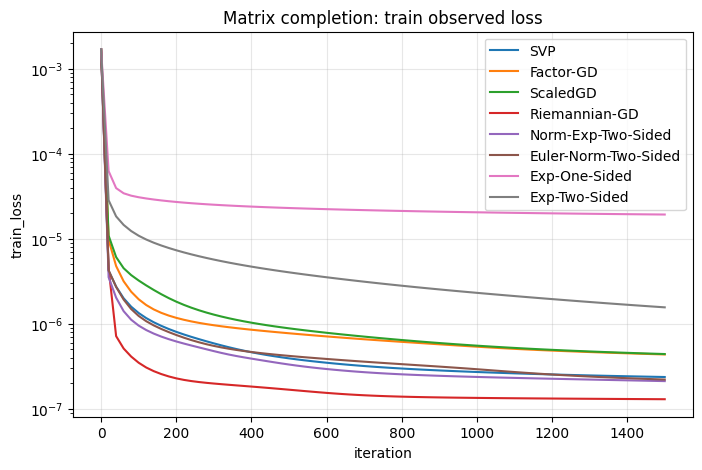

saved figure: figures/single_mc_val_loss.png


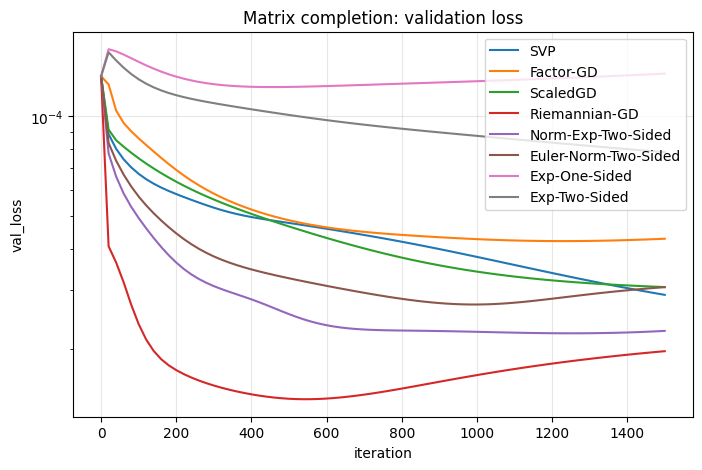

saved figure: figures/single_mc_test_loss.png


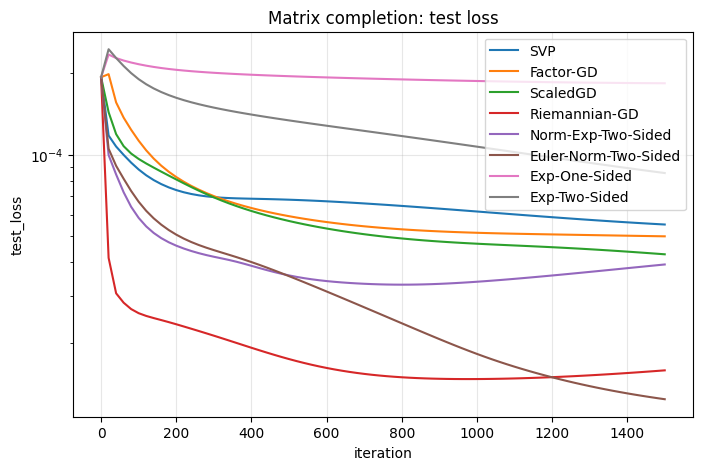

saved figure: figures/single_mc_full_error.png


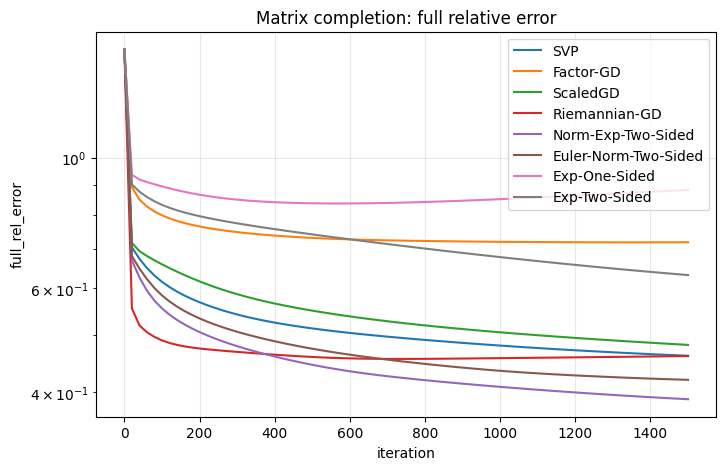

saved figure: figures/single_mc_rank.png


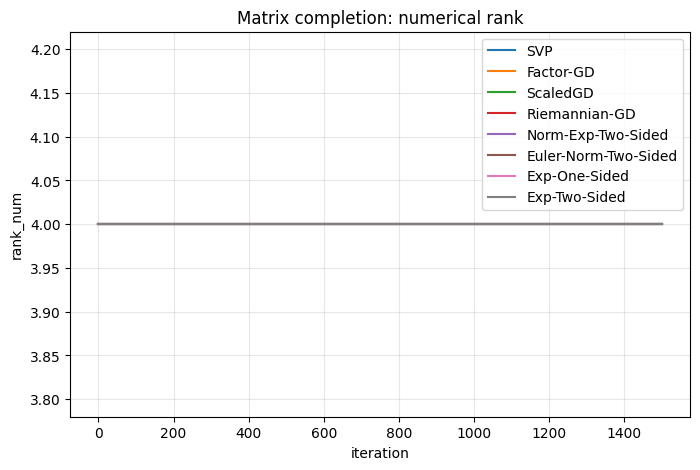

saved figure: figures/single_mc_final_test_loss.png


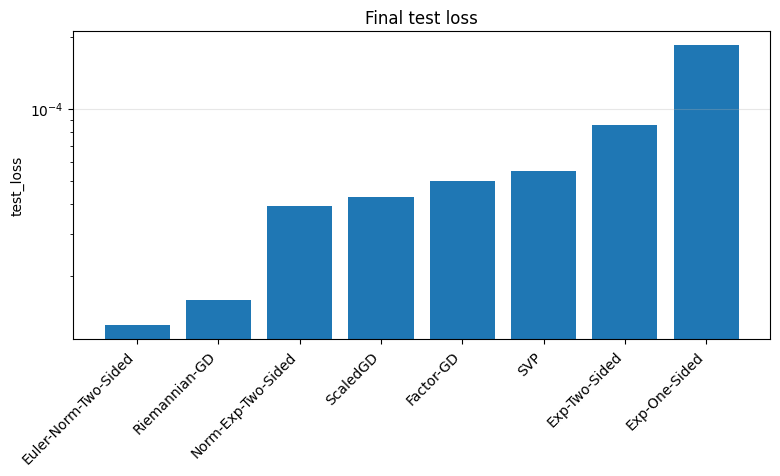

saved figure: figures/single_mc_final_full_error.png


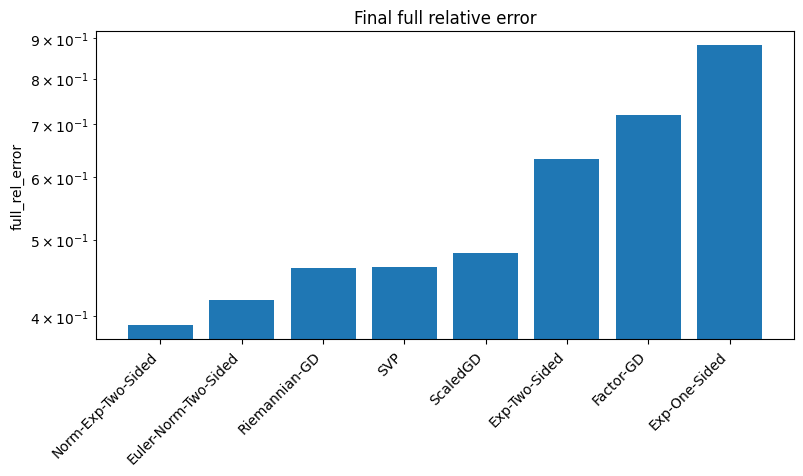

In [8]:
plot_histories(histories, 'train_loss', 'Matrix completion: train observed loss', filename='single_mc_train_loss.png')
plot_histories(histories, 'val_loss', 'Matrix completion: validation loss', filename='single_mc_val_loss.png')
plot_histories(histories, 'test_loss', 'Matrix completion: test loss', filename='single_mc_test_loss.png')
plot_histories(histories, 'full_rel_error', 'Matrix completion: full relative error', filename='single_mc_full_error.png')
plot_histories(histories, 'rank_num', 'Matrix completion: numerical rank', logy=False, filename='single_mc_rank.png')
plot_summary_bars(summary, 'test_loss', 'Final test loss', filename='single_mc_final_test_loss.png')
plot_summary_bars(summary, 'full_rel_error', 'Final full relative error', filename='single_mc_final_full_error.png')


# Experiment B. Multi-seed проверка

Для финальной версии курсовой лучше поставить `seeds=range(10)` или `range(20)`. В fast-режиме оставлено 5 seed, чтобы ноутбук быстро проверялся.


In [9]:
def run_single_mc_seed(seed: int, obs_prob=0.30, cond=50.0, true_rank=4, fit_rank=4,
                       m=50, n=45, noise_std=1e-3, mode='fast', n_iter=600, tune_iter=150,
                       methods_subset: Optional[List[str]] = None,
                       include_exp_old=True, include_extra=False, include_nuclear=False):
    problem, A0, r, M_star = make_matrix_completion_instance(
        m=m, n=n, true_rank=true_rank, fit_rank=fit_rank,
        cond=cond, obs_prob=obs_prob, noise_std=noise_std, seed=seed,
    )
    configs = matrix_completion_configs(mode=mode, include_exp_old=include_exp_old,
                                        include_extra=include_extra, include_nuclear=include_nuclear)
    if methods_subset is not None:
        configs = {k: v for k, v in configs.items() if k in methods_subset}

    histories, solutions, best_params, tuning_trials, boundary_flags = tune_and_run(
        problem, A0, r, configs,
        tune_iter=tune_iter, n_iter=n_iter, eval_every=max(20, n_iter // 30),
        score_key='val_loss', verbose=False,
    )
    summary = summarize_histories(histories)
    summary['seed'] = seed
    summary['obs_prob'] = obs_prob
    summary['cond'] = cond
    summary['true_rank'] = true_rank
    summary['fit_rank'] = fit_rank
    summary['m'] = m
    summary['n'] = n

    p = best_params_to_frame(best_params, boundary_flags)
    p['seed'] = seed
    p['obs_prob'] = obs_prob
    p['cond'] = cond
    p['fit_rank'] = fit_rank
    return summary, p


def run_multiseed_mc(seeds=range(5), **kwargs):
    all_rows = []
    all_params = []
    for seed in seeds:
        print(f'Running seed {seed}...')
        summary, params = run_single_mc_seed(seed=seed, **kwargs)
        all_rows.append(summary)
        all_params.append(params)
    return pd.concat(all_rows, ignore_index=True), pd.concat(all_params, ignore_index=True)


methods_core = ['SVP', 'Factor-GD', 'ScaledGD', 'Riemannian-GD',
                'Exp-Two-Sided', 'Norm-Exp-Two-Sided', 'Euler-Norm-Two-Sided']

multi_df, multi_params = run_multiseed_mc(
    seeds=range(5 if DEFAULT_MODE == 'fast' else 10),
    obs_prob=0.30, cond=50.0, true_rank=4, fit_rank=4,
    mode=DEFAULT_MODE,
    n_iter=600 if DEFAULT_MODE == 'fast' else 1200,
    tune_iter=150 if DEFAULT_MODE == 'fast' else 300,
    methods_subset=methods_core,
)

multi_agg = aggregate_mean_std(multi_df, ['method'], ['test_loss', 'full_rel_error', 'hidden_clean_loss', 'time'])
display(multi_agg.sort_values('test_loss_mean'))

save_df(multi_df, 'multi_seed_raw')
save_df(multi_params, 'multi_seed_best_params')
save_df(multi_agg, 'multi_seed_aggregate')


Running seed 0...
Running seed 1...
Running seed 2...
Running seed 3...
Running seed 4...
Running seed 5...
Running seed 6...
Running seed 7...
Running seed 8...
Running seed 9...


,method,test_loss_mean,test_loss_std,test_loss_median,full_rel_error_mean,full_rel_error_std,full_rel_error_median,hidden_clean_loss_mean,hidden_clean_loss_std,hidden_clean_loss_median,time_mean,time_std,time_median
5,SVP,0.000078,0.000047,0.000055,0.580934,0.110014,0.564977,0.000100,0.000037,0.000095,1.414845,0.740476,1.181875
4,Riemannian-GD,0.000079,0.000054,0.000062,0.564580,0.080386,0.539151,0.000091,0.000027,0.000083,2.129234,1.117307,1.466216
0,Euler-Norm-Two-Sided,0.000081,0.000044,0.000072,0.587487,0.094631,0.600603,0.000100,0.000031,0.000105,1.624792,0.735445,1.380159
3,Norm-Exp-Two-Sided,0.000086,0.000041,0.000071,0.580074,0.095790,0.610012,0.000097,0.000030,0.000105,1.736096,0.372936,1.631902
2,Factor-GD,0.000087,0.000055,0.000084,0.563842,0.130357,0.590280,0.000094,0.000042,0.000100,0.185033,0.039623,0.165151
6,ScaledGD,0.000090,0.000039,0.000078,0.606808,0.082709,0.607751,0.000105,0.000029,0.000101,0.261559,0.026109,0.254202
1,Exp-Two-Sided,0.000207,0.000142,0.000168,0.883565,0.249067,0.833433,0.000202,0.000077,0.000191,0.754846,0.053358,0.736767


saved table: results/multi_seed_raw.csv
saved table: results/multi_seed_best_params.csv
saved table: results/multi_seed_aggregate.csv


saved figure: figures/multi_seed_full_rel_error_boxplot.png


<Figure size 1000x400 with 0 Axes>

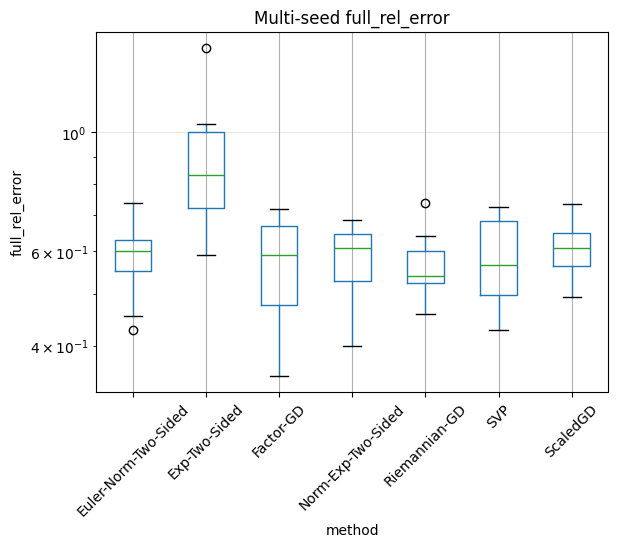

saved figure: figures/multi_seed_test_loss_boxplot.png


<Figure size 1000x400 with 0 Axes>

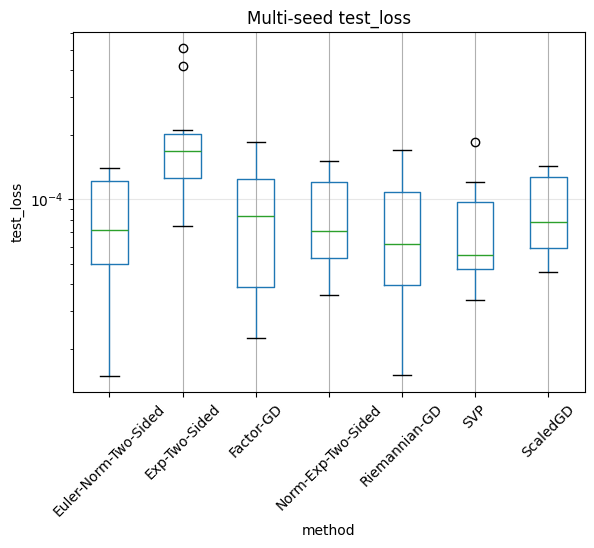

In [10]:
plot_multiseed_boxplots(multi_df, 'full_rel_error', filename='multi_seed_full_rel_error_boxplot.png')
plot_multiseed_boxplots(multi_df, 'test_loss', filename='multi_seed_test_loss_boxplot.png')


# Experiment C. Sweep по доле наблюдений

Здесь корректная интерпретация обычно такая: нормированные схемы должны стабильно улучшать старую Exp-Two-Sided, но не обязаны всегда превосходить ScaledGD/SVP.


In [11]:
def run_obs_prob_sweep(obs_probs=(0.10, 0.20, 0.30, 0.50), seeds=range(3), **kwargs):
    rows = []
    params_rows = []
    for p in obs_probs:
        print(f'obs_prob={p}')
        df, params = run_multiseed_mc(seeds=seeds, obs_prob=p, **kwargs)
        rows.append(df)
        params_rows.append(params)
    return pd.concat(rows, ignore_index=True), pd.concat(params_rows, ignore_index=True)

obs_sweep_df, obs_sweep_params = run_obs_prob_sweep(
    obs_probs=(0.10, 0.20, 0.30, 0.50),
    seeds=range(3 if DEFAULT_MODE == 'fast' else 5),
    cond=50.0, true_rank=4, fit_rank=4,
    mode=DEFAULT_MODE,
    n_iter=500 if DEFAULT_MODE == 'fast' else 1000,
    tune_iter=120 if DEFAULT_MODE == 'fast' else 250,
    methods_subset=methods_core,
)

obs_agg = aggregate_mean_std(obs_sweep_df, ['obs_prob', 'method'], ['test_loss', 'full_rel_error'])
display(obs_agg.sort_values(['obs_prob', 'test_loss_mean']))

save_df(obs_sweep_df, 'obs_prob_sweep_raw')
save_df(obs_agg, 'obs_prob_sweep_aggregate')


obs_prob=0.1
Running seed 0...
Running seed 1...
Running seed 2...
Running seed 3...
Running seed 4...
obs_prob=0.2
Running seed 0...
Running seed 1...
Running seed 2...
Running seed 3...
Running seed 4...
obs_prob=0.3
Running seed 0...
Running seed 1...
Running seed 2...
Running seed 3...
Running seed 4...
obs_prob=0.5
Running seed 0...
Running seed 1...
Running seed 2...
Running seed 3...
Running seed 4...


,obs_prob,method,test_loss_mean,test_loss_std,test_loss_median,full_rel_error_mean,full_rel_error_std,full_rel_error_median
2,0.1,Factor-GD,0.000263,0.000058,0.000285,0.955504,0.034292,0.953587
1,0.1,Exp-Two-Sided,0.000274,0.000069,0.000291,0.972427,0.065172,0.957658
4,0.1,Riemannian-GD,0.000280,0.000101,0.000285,0.928387,0.019423,0.918591
5,0.1,SVP,0.000287,0.000124,0.000285,0.940813,0.023849,0.933615
0,0.1,Euler-Norm-Two-Sided,0.000288,0.000098,0.000294,0.930069,0.013641,0.925700
3,0.1,Norm-Exp-Two-Sided,0.000290,0.000093,0.000301,0.929833,0.013572,0.926968
6,0.1,ScaledGD,0.000291,0.000095,0.000294,0.929417,0.013602,0.924214
10,0.2,Norm-Exp-Two-Sided,0.000161,0.000047,0.000178,0.783445,0.097190,0.761705
12,0.2,SVP,0.000163,0.000089,0.000115,0.780782,0.087700,0.809216
7,0.2,Euler-Norm-Two-Sided,0.000177,0.000133,0.000107,0.749463,0.075041,0.771188


saved table: results/obs_prob_sweep_raw.csv
saved table: results/obs_prob_sweep_aggregate.csv


saved figure: figures/obs_prob_sweep_full_rel_error.png


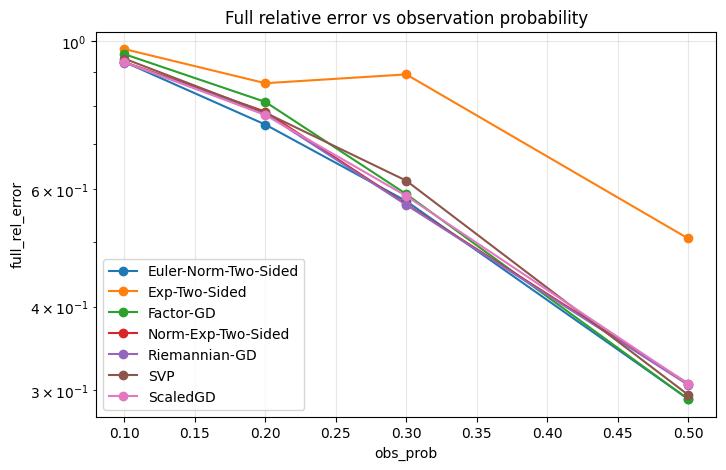

saved figure: figures/obs_prob_sweep_test_loss.png


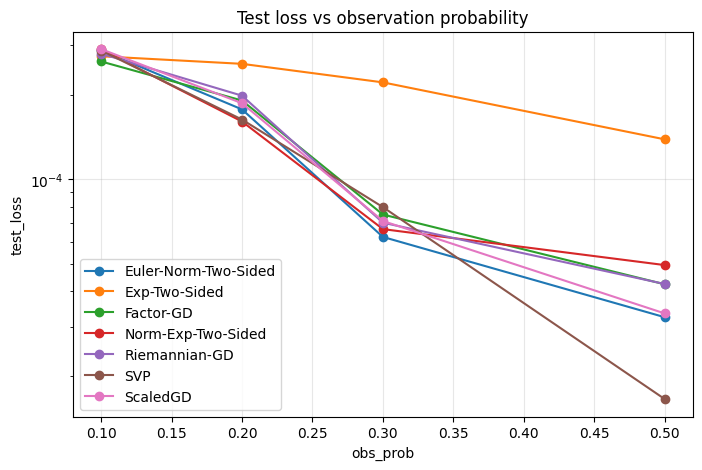

In [12]:
plot_sweep(obs_sweep_df, 'obs_prob', 'full_rel_error', 'Full relative error vs observation probability', filename='obs_prob_sweep_full_rel_error.png')
plot_sweep(obs_sweep_df, 'obs_prob', 'test_loss', 'Test loss vs observation probability', filename='obs_prob_sweep_test_loss.png')


# Experiment D. Sweep по condition number

Это ключевой эксперимент для курсовой: старый Exp-Two-Sided содержит множители \(\Sigma^2\), а нормированная схема заменяет их на проекторы.


In [13]:
def run_condition_sweep(conds=(1, 10, 100, 1000), seeds=range(3), **kwargs):
    rows = []
    params_rows = []
    for c in conds:
        print(f'cond={c}')
        df, params = run_multiseed_mc(seeds=seeds, cond=c, **kwargs)
        rows.append(df)
        params_rows.append(params)
    return pd.concat(rows, ignore_index=True), pd.concat(params_rows, ignore_index=True)

cond_methods = ['SVP', 'ScaledGD', 'Riemannian-GD', 'Exp-Two-Sided', 'Norm-Exp-Two-Sided', 'Euler-Norm-Two-Sided']
cond_sweep_df, cond_sweep_params = run_condition_sweep(
    conds=(1, 10, 100, 1000),
    seeds=range(3 if DEFAULT_MODE == 'fast' else 5),
    obs_prob=0.30, true_rank=4, fit_rank=4,
    mode=DEFAULT_MODE,
    n_iter=500 if DEFAULT_MODE == 'fast' else 1000,
    tune_iter=120 if DEFAULT_MODE == 'fast' else 250,
    methods_subset=cond_methods,
)

cond_agg = aggregate_mean_std(cond_sweep_df, ['cond', 'method'], ['test_loss', 'full_rel_error'])
display(cond_agg.sort_values(['cond', 'full_rel_error_mean']))

save_df(cond_sweep_df, 'condition_sweep_raw')
save_df(cond_agg, 'condition_sweep_aggregate')


cond=1
Running seed 0...
Running seed 1...
Running seed 2...
Running seed 3...
Running seed 4...
cond=10
Running seed 0...
Running seed 1...
Running seed 2...
Running seed 3...
Running seed 4...
cond=100
Running seed 0...
Running seed 1...
Running seed 2...
Running seed 3...
Running seed 4...
cond=1000
Running seed 0...
Running seed 1...
Running seed 2...
Running seed 3...
Running seed 4...


,cond,method,test_loss_mean,test_loss_std,test_loss_median,full_rel_error_mean,full_rel_error_std,full_rel_error_median
1,1,Exp-Two-Sided,0.000023,0.000042,0.000004,0.221862,0.229969,0.124705
4,1,SVP,0.000028,0.000055,0.000003,0.229254,0.273785,0.102882
2,1,Norm-Exp-Two-Sided,0.000030,0.000060,0.000003,0.231143,0.288712,0.102478
3,1,Riemannian-GD,0.000028,0.000055,0.000003,0.231452,0.272941,0.103903
0,1,Euler-Norm-Two-Sided,0.000029,0.000056,0.000003,0.234690,0.277627,0.106113
5,1,ScaledGD,0.000034,0.000056,0.000009,0.297338,0.249751,0.192206
10,10,SVP,0.000071,0.000037,0.000056,0.494950,0.157354,0.452073
6,10,Euler-Norm-Two-Sided,0.000074,0.000033,0.000077,0.536969,0.100103,0.484564
11,10,ScaledGD,0.000087,0.000053,0.000085,0.559500,0.051600,0.549589
9,10,Riemannian-GD,0.000085,0.000055,0.000078,0.562465,0.133170,0.522367


saved table: results/condition_sweep_raw.csv
saved table: results/condition_sweep_aggregate.csv


saved figure: figures/condition_sweep_full_rel_error.png


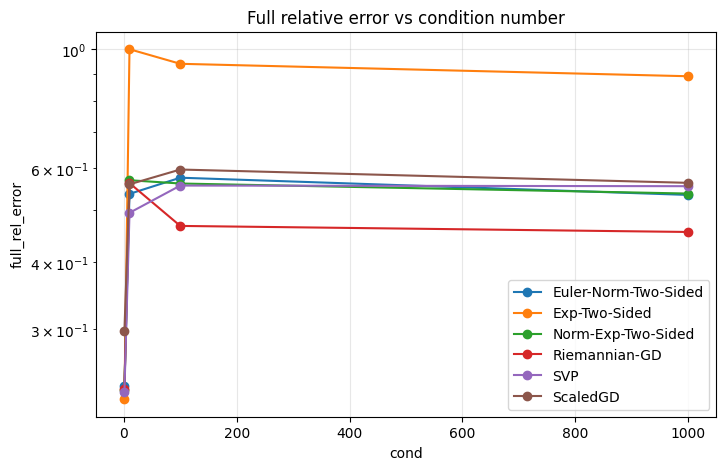

saved figure: figures/condition_sweep_test_loss.png


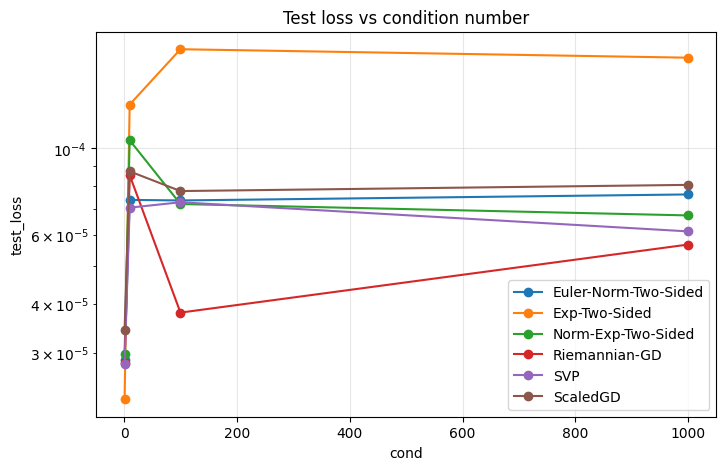

In [14]:
plot_sweep(cond_sweep_df, 'cond', 'full_rel_error', 'Full relative error vs condition number', filename='condition_sweep_full_rel_error.png')
plot_sweep(cond_sweep_df, 'cond', 'test_loss', 'Test loss vs condition number', filename='condition_sweep_test_loss.png')


# Experiment E. Rank mismatch

Дополнительно считаем oracle best-rank-r ошибку самой истинной матрицы. Это помогает объяснить, почему при быстро убывающем спектре \(r<r_\star\) иногда даёт меньшую test/full error.


In [15]:
def run_rank_mismatch_sweep(fit_ranks=(2, 3, 4, 6, 8, 12), seeds=range(3), **kwargs):
    rows = []
    params_rows = []
    for rr in fit_ranks:
        print(f'fit_rank={rr}')
        df, params = run_multiseed_mc(seeds=seeds, fit_rank=rr, **kwargs)
        rows.append(df)
        params_rows.append(params)
    return pd.concat(rows, ignore_index=True), pd.concat(params_rows, ignore_index=True)

rank_methods = ['SVP', 'ScaledGD', 'Riemannian-GD', 'Norm-Exp-Two-Sided', 'Euler-Norm-Two-Sided']
fit_ranks = (2, 3, 4, 6, 8)
rank_sweep_df, rank_sweep_params = run_rank_mismatch_sweep(
    fit_ranks=fit_ranks,
    seeds=range(3 if DEFAULT_MODE == 'fast' else 5),
    obs_prob=0.30, cond=50.0, true_rank=4,
    mode=DEFAULT_MODE,
    n_iter=500 if DEFAULT_MODE == 'fast' else 1000,
    tune_iter=120 if DEFAULT_MODE == 'fast' else 250,
    methods_subset=rank_methods,
)

# Oracle errors averaged over the same generated true matrices.
oracle_rows = []
for seed in range(3 if DEFAULT_MODE == 'fast' else 5):
    problem_tmp, A0_tmp, r_tmp, M_tmp = make_matrix_completion_instance(
        m=50, n=45, true_rank=4, fit_rank=4,
        cond=50.0, obs_prob=0.30, noise_std=1e-3, seed=seed,
    )
    tmp = best_rank_errors(M_tmp, fit_ranks)
    tmp['seed'] = seed
    oracle_rows.append(tmp)
oracle_rank_df = pd.concat(oracle_rows, ignore_index=True)
oracle_rank_agg = aggregate_mean_std(oracle_rank_df, ['fit_rank'], ['oracle_best_rank_rel_error'])

rank_agg = aggregate_mean_std(rank_sweep_df, ['fit_rank', 'method'], ['test_loss', 'full_rel_error'])
display(rank_agg.sort_values(['fit_rank', 'test_loss_mean']))
display(oracle_rank_agg)

save_df(rank_sweep_df, 'rank_mismatch_raw')
save_df(rank_agg, 'rank_mismatch_aggregate')
save_df(oracle_rank_agg, 'rank_mismatch_oracle_best_rank')


fit_rank=2
Running seed 0...
Running seed 1...
Running seed 2...
Running seed 3...
Running seed 4...
fit_rank=3
Running seed 0...
Running seed 1...
Running seed 2...
Running seed 3...
Running seed 4...
fit_rank=4
Running seed 0...
Running seed 1...
Running seed 2...
Running seed 3...
Running seed 4...
fit_rank=6
Running seed 0...
Running seed 1...
Running seed 2...
Running seed 3...
Running seed 4...
fit_rank=8
Running seed 0...
Running seed 1...
Running seed 2...
Running seed 3...
Running seed 4...


,fit_rank,method,test_loss_mean,test_loss_std,test_loss_median,full_rel_error_mean,full_rel_error_std,full_rel_error_median
3,2,SVP,0.000004,0.000001,0.000004,0.108895,0.006640,0.113023
0,2,Euler-Norm-Two-Sided,0.000006,0.000003,0.000005,0.192369,0.181628,0.113693
1,2,Norm-Exp-Two-Sided,0.000006,0.000003,0.000005,0.192378,0.181684,0.113629
4,2,ScaledGD,0.000007,0.000003,0.000006,0.248698,0.165549,0.201530
2,2,Riemannian-GD,0.000011,0.000012,0.000005,0.259209,0.204744,0.114259
7,3,Riemannian-GD,0.000034,0.000028,0.000024,0.348213,0.072450,0.362160
8,3,SVP,0.000041,0.000037,0.000025,0.374684,0.146367,0.330778
6,3,Norm-Exp-Two-Sided,0.000050,0.000044,0.000028,0.459452,0.178223,0.572481
9,3,ScaledGD,0.000052,0.000041,0.000029,0.504172,0.100783,0.559741
5,3,Euler-Norm-Two-Sided,0.000052,0.000044,0.000028,0.487283,0.172741,0.575659


,fit_rank,oracle_best_rank_rel_error_mean,oracle_best_rank_rel_error_std,oracle_best_rank_rel_error_median
0,2,7.348144e-02,2.501854e-17,7.348144e-02
1,3,1.924938e-02,4.906539e-18,1.924938e-02
2,4,5.965835e-16,2.336927e-16,5.138852e-16
3,6,6.085137e-16,2.310805e-16,5.259084e-16
4,8,6.183832e-16,2.278306e-16,5.363279e-16


saved table: results/rank_mismatch_raw.csv
saved table: results/rank_mismatch_aggregate.csv
saved table: results/rank_mismatch_oracle_best_rank.csv


saved figure: figures/rank_mismatch_full_rel_error.png


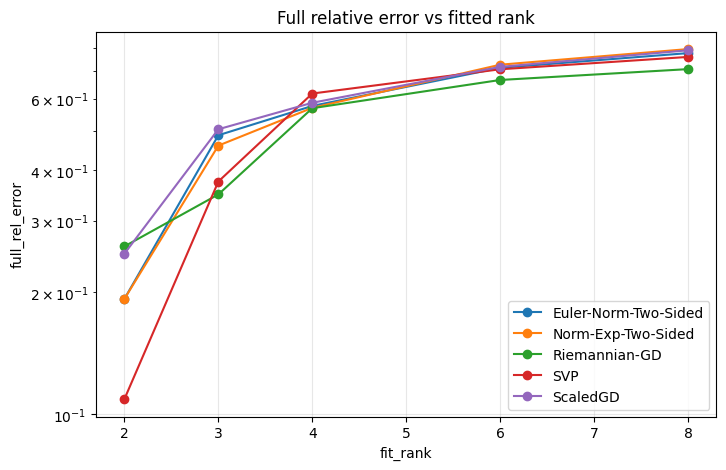

saved figure: figures/rank_mismatch_test_loss.png


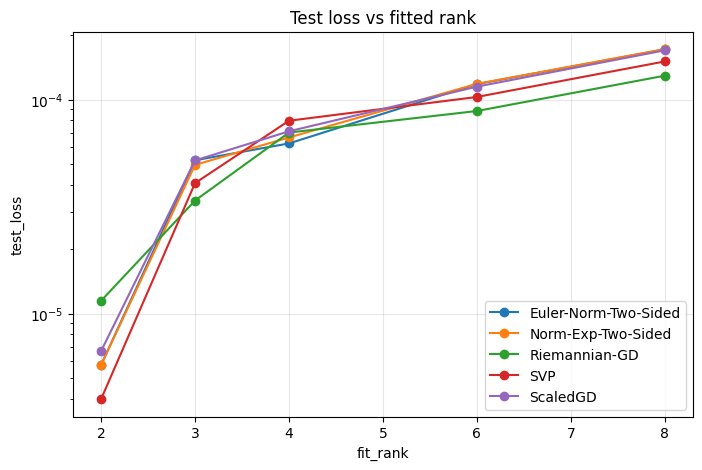

saved figure: figures/rank_mismatch_oracle_error.png


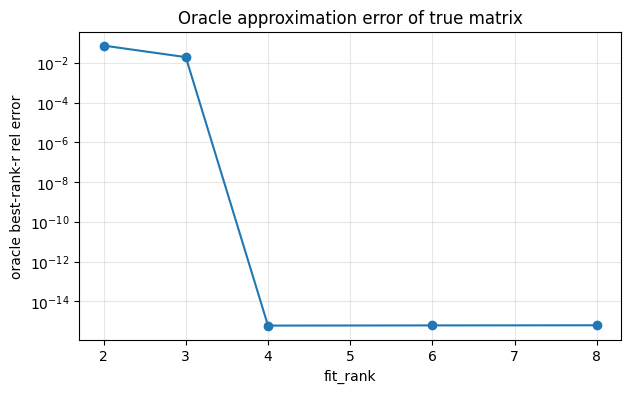

In [16]:
plot_sweep(rank_sweep_df, 'fit_rank', 'full_rel_error', 'Full relative error vs fitted rank', filename='rank_mismatch_full_rel_error.png')
plot_sweep(rank_sweep_df, 'fit_rank', 'test_loss', 'Test loss vs fitted rank', filename='rank_mismatch_test_loss.png')

plt.figure(figsize=(7, 4))
plt.plot(oracle_rank_agg['fit_rank'], oracle_rank_agg['oracle_best_rank_rel_error_mean'], marker='o')
plt.yscale('log')
plt.xlabel('fit_rank')
plt.ylabel('oracle best-rank-r rel error')
plt.title('Oracle approximation error of true matrix')
plt.grid(True, alpha=0.3)
save_current_fig('rank_mismatch_oracle_error.png')
plt.show()


# Experiment F. Ablation study

Здесь главная проверка: улучшение идёт от нормировки через \(A^+\), а не от случайного преимущества конкретной реализации.


In [17]:
ablation_methods = ['Exp-Two-Sided', 'Norm-Exp-Two-Sided', 'Euler-Norm-Two-Sided', 'Riemannian-GD', 'ScaledGD']
problem_ab, A0_ab, r_ab, M_ab = make_matrix_completion_instance(
    m=50, n=45, true_rank=4, fit_rank=4,
    cond=50.0, obs_prob=0.30, noise_std=1e-3, seed=123,
)
configs_ab = matrix_completion_configs(mode=DEFAULT_MODE, include_exp_old=True, include_extra=False, include_nuclear=False)
configs_ab = {k: v for k, v in configs_ab.items() if k in ablation_methods}

hist_ab, sol_ab, params_ab, trials_ab, boundary_ab = tune_and_run(
    problem_ab, A0_ab, r_ab, configs_ab,
    tune_iter=200 if DEFAULT_MODE == 'fast' else 400,
    n_iter=800 if DEFAULT_MODE == 'fast' else 1500,
    eval_every=20,
    score_key='val_loss',
)
summary_ab = summarize_histories(hist_ab)
params_ab_df = best_params_to_frame(params_ab, boundary_ab)

display(params_ab_df)
display(summary_ab[['method', 'train_loss', 'val_loss', 'test_loss', 'hidden_clean_loss', 'full_rel_error', 'rank_num', 'time']])

save_df(params_ab_df, 'ablation_best_params')
save_df(summary_ab, 'ablation_summary')


ScaledGD              : best params = {'eta': 100.0, 'damping': 1e-06}, full val_loss = 1.370e-04  [boundary eta]
Riemannian-GD         : best params = {'eta': 908.5175756516871}, full val_loss = 2.239e-05
Norm-Exp-Two-Sided    : best params = {'eta': 464.1588833612773, 'pinv_eps': 1e-12}, full val_loss = 1.249e-04
Euler-Norm-Two-Sided  : best params = {'eta': 316.2277660168379, 'project_rank': 1.0, 'pinv_eps': 1e-12}, full val_loss = 1.270e-04
Exp-Two-Sided         : best params = {'eta': 3831.186849557293}, full val_loss = 2.444e-04


,method,eta,damping,eta_on_grid_boundary,pinv_eps,project_rank
0,ScaledGD,100.000000,0.000001,True,NaN,NaN
1,Riemannian-GD,908.517576,NaN,False,NaN,NaN
2,Norm-Exp-Two-Sided,464.158883,NaN,False,1.000000e-12,NaN
3,Euler-Norm-Two-Sided,316.227766,NaN,False,1.000000e-12,1.0
4,Exp-Two-Sided,3831.186850,NaN,False,NaN,NaN


,method,train_loss,val_loss,test_loss,hidden_clean_loss,full_rel_error,rank_num,time
2,Norm-Exp-Two-Sided,3.178687e-07,0.000125,0.000032,0.000073,0.511528,4,4.249581
3,Euler-Norm-Two-Sided,3.504749e-07,0.000127,0.000035,0.000073,0.512201,4,2.198596
0,ScaledGD,5.136731e-07,0.000137,0.000039,0.000080,0.535748,4,0.316080
1,Riemannian-GD,1.955958e-07,0.000022,0.000098,0.000050,0.426721,4,1.692935
4,Exp-Two-Sided,3.475056e-06,0.000244,0.000239,0.000241,0.925593,4,1.021842


saved table: results/ablation_best_params.csv
saved table: results/ablation_summary.csv


saved figure: figures/ablation_test_loss.png


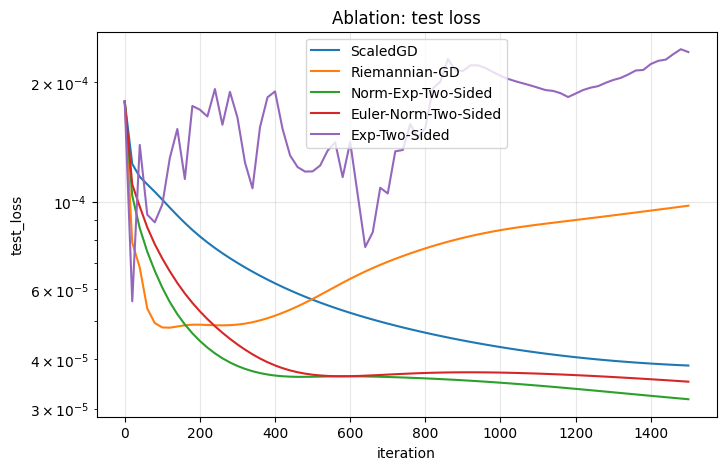

saved figure: figures/ablation_full_rel_error.png


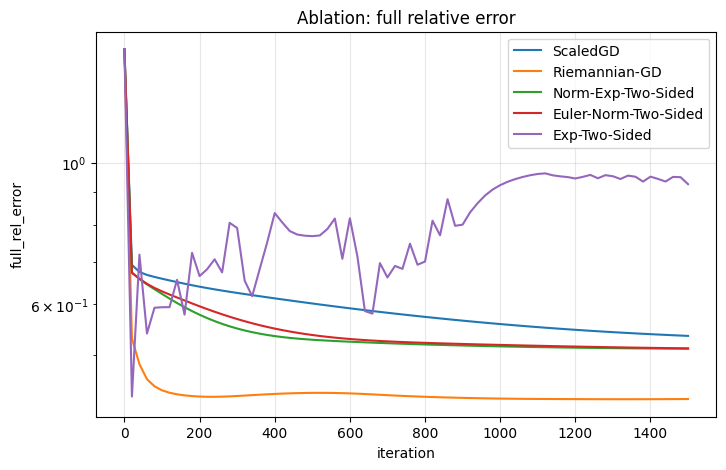

In [18]:
plot_histories(hist_ab, 'test_loss', 'Ablation: test loss', filename='ablation_test_loss.png')
plot_histories(hist_ab, 'full_rel_error', 'Ablation: full relative error', filename='ablation_full_rel_error.png')


# Experiment G. Nuclear-Prox separately

`Nuclear-Prox` не сохраняет фиксированный ранг, поэтому его лучше не смешивать с главной таблицей фиксированного ранга. Но можно показать как отдельный classical baseline.


In [19]:
configs_np = matrix_completion_configs(mode=DEFAULT_MODE, include_exp_old=False, include_extra=False, include_nuclear=True)
configs_np = {k: v for k, v in configs_np.items() if k in ['Nuclear-Prox', 'SVP', 'ScaledGD', 'Norm-Exp-Two-Sided', 'Euler-Norm-Two-Sided']}

hist_np, sol_np, params_np, trials_np, boundary_np = tune_and_run(
    problem, A0, r, configs_np,
    tune_iter=150 if DEFAULT_MODE == 'fast' else 300,
    n_iter=600 if DEFAULT_MODE == 'fast' else 1200,
    eval_every=20,
    score_key='val_loss',
)
summary_np = summarize_histories(hist_np)
params_np_df = best_params_to_frame(params_np, boundary_np)

display(params_np_df)
display(summary_np[['method', 'test_loss', 'full_rel_error', 'rank_num', 'time']])

save_df(params_np_df, 'nuclear_prox_best_params')
save_df(summary_np, 'nuclear_prox_summary')


SVP                   : best params = {'eta': 348.0700588428413}, full val_loss = 3.378e-05
ScaledGD              : best params = {'eta': 100.0, 'damping': 1e-06}, full val_loss = 3.210e-05  [boundary eta]
Norm-Exp-Two-Sided    : best params = {'eta': 464.1588833612773, 'pinv_eps': 1e-12}, full val_loss = 2.226e-05
Euler-Norm-Two-Sided  : best params = {'eta': 316.2277660168379, 'project_rank': 1.0, 'pinv_eps': 1e-12}, full val_loss = 2.827e-05
Nuclear-Prox          : best params = {'eta': 316.2277660168379, 'lamb': 3.1622776601683795e-05}, full val_loss = 1.759e-05


,method,eta,eta_on_grid_boundary,damping,pinv_eps,project_rank,lamb
0,SVP,348.070059,False,NaN,NaN,NaN,NaN
1,ScaledGD,100.000000,True,0.000001,NaN,NaN,NaN
2,Norm-Exp-Two-Sided,464.158883,False,NaN,1.000000e-12,NaN,NaN
3,Euler-Norm-Two-Sided,316.227766,False,NaN,1.000000e-12,1.0,NaN
4,Nuclear-Prox,316.227766,False,NaN,NaN,NaN,0.000032


,method,test_loss,full_rel_error,rank_num,time
3,Euler-Norm-Two-Sided,0.000015,0.427312,4,1.442552
2,Norm-Exp-Two-Sided,0.000036,0.399798,4,1.617593
1,ScaledGD,0.000045,0.494679,4,0.280029
4,Nuclear-Prox,0.000046,0.293298,5,1.277540
0,SVP,0.000059,0.471371,4,1.190725


saved table: results/nuclear_prox_best_params.csv
saved table: results/nuclear_prox_summary.csv


# Experiment H. Runtime and scalability

Runtime измеряется без повторного tuning внутри каждого повтора: сначала подбираем параметры один раз, затем несколько раз меряем финальный запуск. Это честнее и менее шумно.


In [20]:
def time_one_runner(runner, problem, A0, r, params, n_iter=200, repeats=5):
    times = []
    last_hist = None
    last_A = None
    for rep in range(repeats):
        t0 = time.perf_counter()
        hist, A = runner(problem, A0, r=r, n_iter=n_iter, eval_every=n_iter,
                         method_name='tmp', **params)
        elapsed = time.perf_counter() - t0
        times.append(elapsed)
        last_hist = hist
        last_A = A
    return float(np.mean(times)), float(np.std(times)), last_hist, last_A


def runtime_scale_experiment(sizes=((30, 30), (50, 50), (80, 80)), seed=0, repeats=5):
    rows = []
    methods = ['SVP', 'ScaledGD', 'Riemannian-GD', 'Norm-Exp-Two-Sided']
    for m, n in sizes:
        print(f'size={m}x{n}')
        problem_rt, A0_rt, r_rt, M_rt = make_matrix_completion_instance(
            m=m, n=n, true_rank=4, fit_rank=4,
            cond=50.0, obs_prob=0.30, noise_std=1e-3, seed=seed,
        )
        configs_rt = matrix_completion_configs(mode='fast', include_exp_old=False, include_extra=False, include_nuclear=False)
        configs_rt = {k: v for k, v in configs_rt.items() if k in methods}

        # Tune once.
        _, _, params_rt, _, boundary_rt = tune_and_run(
            problem_rt, A0_rt, r_rt, configs_rt,
            tune_iter=80, n_iter=80, eval_every=80,
            score_key='val_loss', verbose=False,
        )

        # Time repeated final runs.
        for method in methods:
            if method not in params_rt:
                continue
            runner = configs_rt[method]['runner']
            mean_t, std_t, hist_last, A_last = time_one_runner(
                runner, problem_rt, A0_rt, r_rt, params_rt[method],
                n_iter=200, repeats=repeats,
            )
            row = log_metrics(problem_rt, A_last, r_rt, method, 200, time.perf_counter())
            row.update({
                'm': m,
                'n': n,
                'mn': m * n,
                'runtime_mean': mean_t,
                'runtime_std': std_t,
                'time_per_iter_mean': mean_t / 200,
                'repeats': repeats,
            })
            rows.append(row)
    return pd.DataFrame(rows)

runtime_df = runtime_scale_experiment(
    sizes=((30, 30), (50, 50), (80, 80)),
    seed=0,
    repeats=3 if DEFAULT_MODE == 'fast' else 5,
)
display(runtime_df[['method', 'm', 'n', 'test_loss', 'full_rel_error', 'runtime_mean', 'runtime_std', 'time_per_iter_mean']].sort_values(['m', 'runtime_mean']))
save_df(runtime_df, 'runtime_scaling')


size=30x30
size=50x50
size=80x80


,method,m,n,test_loss,full_rel_error,runtime_mean,runtime_std,time_per_iter_mean
1,ScaledGD,30,30,0.000815,0.788418,0.026161,0.002836,0.000131
0,SVP,30,30,0.000850,0.805676,0.066698,0.010318,0.000333
2,Riemannian-GD,30,30,0.000833,0.809976,0.079256,0.007157,0.000396
3,Norm-Exp-Two-Sided,30,30,0.000816,0.792274,0.133096,0.002753,0.000665
5,ScaledGD,50,50,0.000138,0.725477,0.049609,0.004252,0.000248
6,Riemannian-GD,50,50,0.000103,0.680574,0.243873,0.008634,0.001219
7,Norm-Exp-Two-Sided,50,50,0.000137,0.726284,0.273701,0.012869,0.001369
4,SVP,50,50,0.000121,0.695367,0.318519,0.137399,0.001593
9,ScaledGD,80,80,0.000021,0.528223,0.074354,0.003375,0.000372
10,Riemannian-GD,80,80,0.000007,0.327103,0.499923,0.015198,0.002500


saved table: results/runtime_scaling.csv


saved figure: figures/runtime_scaling.png


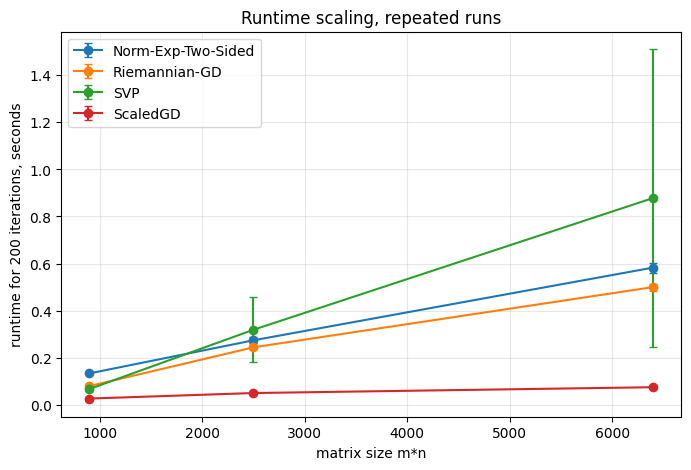

In [21]:
plt.figure(figsize=(8, 5))
for method, g in runtime_df.groupby('method'):
    gg = g.sort_values('mn')
    plt.errorbar(gg['mn'], gg['runtime_mean'], yerr=gg['runtime_std'], marker='o', capsize=3, label=method)
plt.xlabel('matrix size m*n')
plt.ylabel('runtime for 200 iterations, seconds')
plt.title('Runtime scaling, repeated runs')
plt.grid(True, alpha=0.3)
plt.legend()
save_current_fig('runtime_scaling.png')
plt.show()


# Experiment I. Synthetic image inpainting

Это демонстрационный эксперимент на синтетическом изображении. В тексте курсовой лучше писать именно так, а не подавать его как полноценный benchmark на реальных изображениях.


In [ ]:
def make_synthetic_image(h=64, w=64):
    x = np.linspace(0, 1, w)
    y = np.linspace(0, 1, h)
    X, Y = np.meshgrid(x, y)
    img = 0.35 * np.sin(2 * np.pi * X) + 0.35 * np.cos(2 * np.pi * Y)
    img += 0.4 * np.exp(-((X - 0.65)**2 + (Y - 0.35)**2) / 0.02)
    img += 0.25 * ((X > 0.15) & (X < 0.35) & (Y > 0.55) & (Y < 0.8))
    img = img - img.min()
    img = img / img.max()
    return img


def show_image_grid(images: Dict[str, np.ndarray], cols=3, cmap='gray', filename=None):
    names = list(images.keys())
    rows = math.ceil(len(names) / cols)
    plt.figure(figsize=(4 * cols, 4 * rows))
    for i, name in enumerate(names, 1):
        plt.subplot(rows, cols, i)
        plt.imshow(images[name], cmap=cmap, vmin=0, vmax=1)
        plt.title(name)
        plt.axis('off')
    save_current_fig(filename)
    plt.show()


img = make_synthetic_image(64, 64)
seed = 7
rng = np.random.default_rng(seed)
obs_prob = 0.35
train_mask, val_mask, test_mask = split_observed_mask(64, 64, obs_prob, rng)
problem_img = MatrixCompletionProblem(img, train_mask, val_mask, test_mask, noise_std=0.0, seed=seed)
r_img = 8
A0_img = spectral_initialization_mc(problem_img, r_img)

configs_img = matrix_completion_configs(mode=DEFAULT_MODE, include_exp_old=True, include_extra=False, include_nuclear=False)
keep = ['SVP', 'ScaledGD', 'Riemannian-GD', 'Exp-Two-Sided', 'Norm-Exp-Two-Sided', 'Euler-Norm-Two-Sided']
configs_img = {k: v for k, v in configs_img.items() if k in keep}

hist_img, sol_img, params_img, trials_img, boundary_img = tune_and_run(
    problem_img, A0_img, r_img, configs_img,
    tune_iter=150 if DEFAULT_MODE == 'fast' else 300,
    n_iter=700 if DEFAULT_MODE == 'fast' else 1200,
    eval_every=20,
    score_key='val_loss',
)
summary_img = summarize_histories(hist_img)
params_img_df = best_params_to_frame(params_img, boundary_img)

display(params_img_df)
display(summary_img[['method', 'train_loss', 'val_loss', 'test_loss', 'hidden_clean_loss', 'full_rel_error', 'rank_num', 'time']])

save_df(params_img_df, 'inpainting_best_params')
save_df(summary_img, 'inpainting_summary')

observed_img = np.zeros_like(img)
observed_mask = train_mask | val_mask | test_mask
observed_img[observed_mask] = img[observed_mask]
imgs = {'Original': img, 'Observed': observed_img, 'Init': np.clip(A0_img, 0, 1)}
for name, A in sol_img.items():
    imgs[name] = np.clip(A, 0, 1)
show_image_grid(imgs, cols=3, filename='inpainting_grid.png')
plot_histories(hist_img, 'full_rel_error', 'Image inpainting: full relative error', filename='inpainting_full_rel_error.png')
plot_histories(hist_img, 'test_loss', 'Image inpainting: test loss', filename='inpainting_test_loss.png')


SVP                   : best params = {'eta': 1467.7992676220706}, full val_loss = 3.893e-02
ScaledGD              : best params = {'eta': 100.0, 'damping': 1e-06}, full val_loss = 4.122e-02  [boundary eta]
Riemannian-GD         : best params = {'eta': 1467.7992676220706}, full val_loss = 4.312e-02
Norm-Exp-Two-Sided    : best params = {'eta': 1000.0, 'pinv_eps': 1e-12}, full val_loss = 2.491e-02


# Финальная интерпретация

После запуска ноутбука для курсовой стоит брать не отдельные удачные числа, а устойчивые выводы:

1. `Norm-Exp-Two-Sided` и `Euler-Norm-Two-Sided` должны сравниваться прежде всего со старым `Exp-Two-Sided`, потому что основная гипотеза — исправление плохого \(\Sigma^2\)-масштабирования.
2. Если `ScaledGD` или `SVP` иногда лучше, это не ломает работу. Корректная формулировка: нормированные схемы входят в верхнюю группу и существенно улучшают исходный экспоненциальный метод.
3. Если лучший шаг метода оказался на границе grid, эту таблицу надо перепроверить с расширенной сеткой.
4. `Nuclear-Prox` не надо смешивать с методами фиксированного ранга: он решает другую регуляризованную задачу.
5. Для rank mismatch нужно ссылаться на oracle best-rank-r error, иначе результат с \(r<r_\star\) может выглядеть подозрительно.
